# P06 Pandas

- [Slide: Py06 Pandas and data manipulation](https://docs.google.com/presentation/d/1OP8GcjUUWc9MWxfPNW2Ch47iENpXyOKeMKGzSth1UPs/edit?usp=sharing)
- Pandas cheat sheet: https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf
- [stackoverflow: Convert to json](https://stackoverflow.com/questions/20638006/convert-list-of-dictionaries-to-dataframe)

Pandas模仿Matlab或R的dataframe的函式庫。在資料科學逐漸發展的過程，這些資料大多以類似統計軟體或者Excel等試算表（Sheet）的狀態儲存，也就是二維的表格，且通常是直欄為變數、而橫列為資料列。把這些資料讀進Python時，固然可以讀成List-of-dictionary或List-of-list的型態，但大部分資料操作的思考邏輯，都是以欄和列為基礎，例如增加一個欄是refactor以後的結果、或者篩選出某些變數符合條件的資料列，或者依據某個欄來重新排列資料列的位置。而Pandas可以說就是被設計來滿足這樣的需求的，而且隨著資料科學受世人重視，而發展的越來越完整。例如，Pandas中便有以下函式：
1. 讀取CSV `pd.read_csv('data.csv')`或讀取JSON `pd.read_json('data.json')`
2. 取代空值（Replace empty cell） `df.dropna()`、移除重複列 `df.drop_duplicates(inplace = True)`
3. 執行基礎的關聯運算 `df.corr()`

這個章節將更系統化地用實際案例來介紹，
1. 如何subset資料（類似slicing）的功能。
2. 產生一個新變數、觀察一個變數、改變變數型態
3. 計數某個變數、根據某個變數來做計數／加總／彙整、根據數個變數來做計數。
4. 根據某個變數來排序整個dataframe的資料列
5. 樞紐分析與轉換長寬表格。

## Read data

### Read csv: 違規藥品廣告

違規藥品廣告資料集 https://data.nat.gov.tw/dataset/14196

In [62]:
import pandas as pd
drug_df = pd.read_csv('https://raw.githubusercontent.com/p4css/py4css/main/data/drug_156_2.csv', error_bad_lines=False)
# drug_df
drug_df.columns

/var/folders/j3/p4x0mssx55nd8dn903h5wdb00000gn/T/ipykernel_8968/2820388479.py:2: FutureWarning: The error_bad_lines argument has been deprecated and will be removed in a future version. Use on_bad_lines in the future.


  drug_df = pd.read_csv('https://raw.githubusercontent.com/p4css/py4css/main/data/drug_156_2.csv', error_bad_lines=False)


Index(['違規產品名稱', '違規廠商名稱或負責人', '處分機關', '處分日期', '處分法條', '違規情節', '刊播日期',
       '刊播媒體類別', '刊播媒體', '查處情形'],
      dtype='object')

In [3]:
%who

NamespaceMagics	 drug_df	 get_ipython	 json	 pd	 sys	 


In [63]:
drug_df.columns = ['pname', 'cname', 'agency', 'issuedate', 'law', 'fact', 
              'pubDate', 'pubMediaType', 'pubMedia', 'trace']
drug_df.columns
drug_df

,pname,cname,agency,issuedate,law,fact,pubDate,pubMediaType,pubMedia,trace
0,維他肝,豐怡生化科技股份有限公司/朱O,NaN,03 31 2022 12:00AM,NaN,廣告內容誇大不實,02 2 2022 12:00AM,廣播電台,噶瑪蘭廣播電台股份有限公司,NaN
1,現貨澳洲Swisse ULTIBOOST維他命D片calcium vitamin VITAM...,張O雯/張O雯,NaN,01 21 2022 12:00AM,NaN,廣告違規,11 30 2021 12:00AM,網路,蝦皮購物,輔導結案
2,✈日本 代購 參天製藥 處方簽點眼液,蘇O涵/蘇O涵,NaN,01 25 2022 12:00AM,NaN,無照藥商,08 27 2021 12:00AM,網路,蝦皮購物,NaN
3,✈日本 代購 TSUMURA 中將湯 24天包裝,蘇O涵/蘇O涵,NaN,01 25 2022 12:00AM,NaN,無照藥商,08 27 2021 12:00AM,網路,蝦皮購物,輔導結案
4,_Salty.shop 日本代購 樂敦小花,曾O嫺/曾O嫺,NaN,02 17 2022 12:00AM,藥事法第27條,無照藥商,12 6 2021 12:00AM,網路,蝦皮購物,處分結案
...,...,...,...,...,...,...,...,...,...,...
2967,*健人館* 千鶴薄荷棒11g*2個,新東海藥局/ O聰敏,NaN,NaN,藥事法第27條,標示內容與規定不符,05 6 2020 12:00AM,網路,NaN,處分結案
2968,（現貨）GO LIVER DETOX 高之源 護肝排毒膠囊 120粒,連O毅/連O毅,NaN,06 30 2020 12:00AM,藥事法第27條,無照藥商,02 5 2020 12:00AM,網路,蝦皮購物,處分結案
2969,日本帶回樂敦小花新鮮貨,張O萍/張O萍,NaN,06 23 2020 12:00AM,NaN,難以判定產品屬性,03 10 2020 12:00AM,網路,蝦皮購物,輔導結案
2970,全新 洗眼杯 可平信 洗眼 小林製藥 小花 ROHTO Lycee 可搭配生理食鹽水 空汙 ...,盧O/盧O,NaN,09 4 2020 12:00AM,NaN,無照藥商,03 10 2020 12:00AM,網路,蝦皮購物,輔導結案


In [6]:
print(drug_df.pubMediaType)
# print(set(drug_df.pubMediaType))
# drug_df

0       廣播電台
1         網路
2         網路
3         網路
4         網路
        ... 
2967      網路
2968      網路
2969      網路
2970      網路
2971      網路
Name: pubMediaType, Length: 2972, dtype: object


#### Counting

In [10]:
from collections import Counter
type_dict = Counter(drug_df.pubMediaType)
print(type_dict)
print(Counter(drug_df.fact).most_common(10))

Counter({'網路': 2609, '廣播電台': 119, '平面媒體': 117, '電視': 109, '其他': 16, nan: 2})
[('無照藥商', 1434), ('廣告違規', 248), ('無違規', 185), ('其刊登或宣播之廣告內容與原核准廣告內容不符', 134), (nan, 132), ('非藥商刊登或宣播藥物廣告', 108), ('藥品未申請查驗登記', 94), ('刊播未申請核准之廣告', 85), ('廣告內容誇大不實', 67), ('禁藥', 40)]


In [69]:
drug_df.pubMediaType.value_counts()

網路      2609
廣播電台     119
平面媒體     117
電視       109
其他        16
Name: pubMediaType, dtype: int64

In [68]:
drug_df['pubMediaType'].value_counts()

網路      2609
廣播電台     119
平面媒體     117
電視       109
其他        16
Name: pubMediaType, dtype: int64

### Read JSON : Youbike
`df.head()` print out the first 5 entries of data

#### M1. Convert to list of dicts by hand

In [67]:
import requests
data = requests.get('https://tcgbusfs.blob.core.windows.net/blobyoubike/YouBikeTP.gz').json()


# all_list = []
# for k, v in data["retVal"].items():
# #     print(k, v)
#     all_list.append(v)
# print(all_list[:3])


# Using list comprehension
all_list = [v for v in data["retVal"].values()]
    
ubike_df = pd.DataFrame(all_list)
ubike_df.head()

,sno,sna,tot,sbi,sarea,mday,lat,lng,ar,sareaen,snaen,aren,bemp,act
0,0001,捷運市政府站(3號出口),88,0,信義區,20220927232040,25.0408578889,121.567904444,忠孝東路/松仁路(東南側),Xinyi Dist.,MRT Taipei City Hall Stataion(Exit 3)-2,The S.W. side of Road Zhongxiao East Road & Ro...,84,1
1,0002,捷運國父紀念館站(2號出口),16,0,大安區,20220927232022,25.041254,121.55742,忠孝東路四段/光復南路口(西南側),Daan Dist.,MRT S.Y.S Memorial Hall Stataion(Exit 2.),"Sec,4. Zhongxiao E.Rd/GuangFu S. Rd",16,1
2,0004,市民廣場,32,0,信義區,20220927232044,25.0360361111,121.562325,市府路/松壽路(西北側)(鄰近台北101/台北世界貿易中心/台北探索館),Xinyi Dist.,Citizen Square,The N.W. side of Road Shifu & Road Song Shou.,31,1
3,0005,興雅國中,32,2,信義區,20220927232017,25.0365638889,121.5686639,松仁路/松仁路95巷(東南側)(鄰近信義商圈/台北信義威秀影城),Xinyi Dist.,Xingya Jr. High School,"The S.E. side of Road Songren & Ln. 95, Songre...",30,1
4,0006,臺北南山廣場,54,0,信義區,20220927232028,25.034047,121.565973,松智路/松廉路(東北側) (鄰近台北101/信義商圈/台北信義威秀影城),Xinyi Dist.,NAN SHAN PLAZA,The N.E. side of Road Song Zhi & Road Song Lian.,54,1


#### M2. Using built-in function to pandas

In [64]:
# Using pandas built-in function to convert dictionary to pandas df

import requests
data = requests.get('https://tcgbusfs.blob.core.windows.net/blobyoubike/YouBikeTP.gz').json()
ubike_df = pd.DataFrame.from_dict(data['retVal'], orient='index')
ubike_df.head()

,sno,sna,tot,sbi,sarea,mday,lat,lng,ar,sareaen,snaen,aren,bemp,act
0001,0001,捷運市政府站(3號出口),88,0,信義區,20220927231940,25.0408578889,121.567904444,忠孝東路/松仁路(東南側),Xinyi Dist.,MRT Taipei City Hall Stataion(Exit 3)-2,The S.W. side of Road Zhongxiao East Road & Ro...,84,1
0002,0002,捷運國父紀念館站(2號出口),16,0,大安區,20220927231922,25.041254,121.55742,忠孝東路四段/光復南路口(西南側),Daan Dist.,MRT S.Y.S Memorial Hall Stataion(Exit 2.),"Sec,4. Zhongxiao E.Rd/GuangFu S. Rd",16,1
0004,0004,市民廣場,32,0,信義區,20220927231944,25.0360361111,121.562325,市府路/松壽路(西北側)(鄰近台北101/台北世界貿易中心/台北探索館),Xinyi Dist.,Citizen Square,The N.W. side of Road Shifu & Road Song Shou.,31,1
0005,0005,興雅國中,32,2,信義區,20220927231917,25.0365638889,121.5686639,松仁路/松仁路95巷(東南側)(鄰近信義商圈/台北信義威秀影城),Xinyi Dist.,Xingya Jr. High School,"The S.E. side of Road Songren & Ln. 95, Songre...",30,1
0006,0006,臺北南山廣場,54,0,信義區,20220927231928,25.034047,121.565973,松智路/松廉路(東北側) (鄰近台北101/信義商圈/台北信義威秀影城),Xinyi Dist.,NAN SHAN PLAZA,The N.E. side of Road Song Zhi & Road Song Lian.,54,1


## Pandas 1. Observing data

**Oberserving data** `df.info()` and `df.describe()` 觀察各個變數的分佈 to check data type or get basic summary of data 。

### Overview whole df

In [12]:
ubike_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 371 entries, 0001 to 0405
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   sno      371 non-null    object
 1   sna      371 non-null    object
 2   tot      371 non-null    object
 3   sbi      371 non-null    object
 4   sarea    371 non-null    object
 5   mday     371 non-null    object
 6   lat      371 non-null    object
 7   lng      371 non-null    object
 8   ar       371 non-null    object
 9   sareaen  371 non-null    object
 10  snaen    371 non-null    object
 11  aren     371 non-null    object
 12  bemp     371 non-null    object
 13  act      371 non-null    object
dtypes: object(14)
memory usage: 43.5+ KB


In [13]:
drug_df.head()

,pname,cname,agency,issuedate,law,fact,pubDate,pubMediaType,pubMedia,trace
0,維他肝,豐怡生化科技股份有限公司/朱O,NaN,03 31 2022 12:00AM,NaN,廣告內容誇大不實,02 2 2022 12:00AM,廣播電台,噶瑪蘭廣播電台股份有限公司,NaN
1,現貨澳洲Swisse ULTIBOOST維他命D片calcium vitamin VITAM...,張O雯/張O雯,NaN,01 21 2022 12:00AM,NaN,廣告違規,11 30 2021 12:00AM,網路,蝦皮購物,輔導結案
2,✈日本 代購 參天製藥 處方簽點眼液,蘇O涵/蘇O涵,NaN,01 25 2022 12:00AM,NaN,無照藥商,08 27 2021 12:00AM,網路,蝦皮購物,NaN
3,✈日本 代購 TSUMURA 中將湯 24天包裝,蘇O涵/蘇O涵,NaN,01 25 2022 12:00AM,NaN,無照藥商,08 27 2021 12:00AM,網路,蝦皮購物,輔導結案
4,_Salty.shop 日本代購 樂敦小花,曾O嫺/曾O嫺,NaN,02 17 2022 12:00AM,藥事法第27條,無照藥商,12 6 2021 12:00AM,網路,蝦皮購物,處分結案


In [14]:
ubike_df.describe()

,sno,sna,tot,sbi,sarea,mday,lat,lng,ar,sareaen,snaen,aren,bemp,act
count,371,371,371,371,371,371,371,371,371,371,371,371,371,371
unique,371,371,27,30,12,41,369,370,371,12,370,369,40,1
top,0001,捷運市政府站(3號出口),12,0,中山區,20220922232223,25.068530,121.525322,忠孝東路/松仁路(東南側),Zhongshan Dist.,Nangang Park,"The N.S. side of Lianyun St. & Sec. 2, Xinyi Rd.",7,1
freq,1,1,50,54,44,18,2,2,1,44,2,2,32,371


### Access data by index

In [15]:
# Access single row
print(drug_df.iloc[2])

pname           ✈日本 代購 參天製藥 處方簽點眼液
cname                      蘇O涵/蘇O涵
agency                         NaN
issuedate       01 25 2022 12:00AM
law                            NaN
fact                          無照藥商
pubDate         08 27 2021 12:00AM
pubMediaType                    網路
pubMedia                      蝦皮購物
trace                          NaN
Name: 2, dtype: object


In [36]:
# Access single col(variable)
drug_df.pubMediaType
drug_df['pubMediaType']

0       網路
1       網路
2       網路
3       網路
4       網路
        ..
1755    網路
1756    網路
1757    網路
1758    網路
1759    網路
Name: pubMediaType, Length: 1760, dtype: object

In [16]:
# Access single cell
print(drug_df.iloc[2, 0])

✈日本 代購 參天製藥 處方簽點眼液


### Slice and access data

In [17]:
drug_df[:3]

,pname,cname,agency,issuedate,law,fact,pubDate,pubMediaType,pubMedia,trace
0,維他肝,豐怡生化科技股份有限公司/朱O,NaN,03 31 2022 12:00AM,NaN,廣告內容誇大不實,02 2 2022 12:00AM,廣播電台,噶瑪蘭廣播電台股份有限公司,NaN
1,現貨澳洲Swisse ULTIBOOST維他命D片calcium vitamin VITAM...,張O雯/張O雯,NaN,01 21 2022 12:00AM,NaN,廣告違規,11 30 2021 12:00AM,網路,蝦皮購物,輔導結案
2,✈日本 代購 參天製藥 處方簽點眼液,蘇O涵/蘇O涵,NaN,01 25 2022 12:00AM,NaN,無照藥商,08 27 2021 12:00AM,網路,蝦皮購物,NaN


In [18]:
drug_df[1:5]

,pname,cname,agency,issuedate,law,fact,pubDate,pubMediaType,pubMedia,trace
1,現貨澳洲Swisse ULTIBOOST維他命D片calcium vitamin VITAM...,張O雯/張O雯,NaN,01 21 2022 12:00AM,NaN,廣告違規,11 30 2021 12:00AM,網路,蝦皮購物,輔導結案
2,✈日本 代購 參天製藥 處方簽點眼液,蘇O涵/蘇O涵,NaN,01 25 2022 12:00AM,NaN,無照藥商,08 27 2021 12:00AM,網路,蝦皮購物,NaN
3,✈日本 代購 TSUMURA 中將湯 24天包裝,蘇O涵/蘇O涵,NaN,01 25 2022 12:00AM,NaN,無照藥商,08 27 2021 12:00AM,網路,蝦皮購物,輔導結案
4,_Salty.shop 日本代購 樂敦小花,曾O嫺/曾O嫺,NaN,02 17 2022 12:00AM,藥事法第27條,無照藥商,12 6 2021 12:00AM,網路,蝦皮購物,處分結案


In [19]:
drug_df[::100]

,pname,cname,agency,issuedate,law,fact,pubDate,pubMediaType,pubMedia,trace
0,維他肝,豐怡生化科技股份有限公司/朱O,NaN,03 31 2022 12:00AM,NaN,廣告內容誇大不實,02 2 2022 12:00AM,廣播電台,噶瑪蘭廣播電台股份有限公司,NaN
100,泰國正品NIDA戴挪倫膏口腔潰瘍口腔發炎牙痛舌痛潰瘍藥膏燙傷膏,ROCOMO JHONOLYN ROMOLETE/ROCOMO JHONOLYN ROMOLETE,NaN,03 27 2019 12:00AM,NaN,廣告內容誇大不實,08 23 2018 12:00AM,網路,Yahoo!奇摩拍賣,輔導結案
200,桃園現貨供應 日本進口獅王祛痘膏pair acne祛痘 祛痘膏24g 祛粉刺 不傷肌膚,李O漩/李O漩,NaN,05 30 2019 12:00AM,NaN,禁藥,05 28 2019 12:00AM,網路,露天拍賣,相關案件已處分
300,天然燕麥藍色舒緩發癢止癢乳霜,/,NaN,NaN,NaN,販售輸入化粧品藥品,09 11 2013 12:00AM,網路,露天拍賣,處分結案
400,台灣第一三共汎得命膜衣錠（衛署藥製字第030525號）,台灣第一三共股份有限公司/,NaN,NaN,NaN,廣告內容宣稱療效,04 23 2014 12:00AM,網路,台灣第一三共股份有限公司,處分結案
500,預購 特價 小花眼藥水 8ml,wenlin5606/王O聖,NaN,06 3 2016 12:00AM,藥事法第27條藥事法第39條,無照藥商製造或輸入偽藥或禁藥,06 17 2015 12:00AM,網路,露天市集,處分結案
600,【啡閣樓！】日本 興和制藥 Kowa 蚊蟲 止癢液 60ml 空盒 現貨(限量中),goodselina/鍾O林,NaN,NaN,藥事法第39條,藥品未申請查驗登記,08 4 2015 12:00AM,網路,NaN,處分結案
700,淨膚隆軟膏,桐瑛生技事業股份有限公司/,NaN,12 26 2016 12:00AM,NaN,廣告內容誇大不實,06 3 2016 12:00AM,電視,中投有線電視,相關案件已處分
800,滴可明眼用凝膠劑,諾得健康世界股份有限公司/,台南市,01 11 2017 12:00AM,藥事法第66條第2項,廣告內容誇大不實,01 11 2017 12:00AM,平面媒體,NaN,處分結案
900,賀必容,tiara6133/歐O辰,NaN,05 22 2017 12:00AM,藥事法第27條,無照藥商,02 22 2017 12:00AM,網路,蝦皮拍賣,處分結案


### Observe single variable

In [20]:
print(type(drug_df.pubMediaType))
# print(list(drug_df.pubMediaType))

print(drug_df.pubMediaType[:10])

<class 'pandas.core.series.Series'>
0    廣播電台
1      網路
2      網路
3      網路
4      網路
5      網路
6      網路
7      網路
8      網路
9      網路
Name: pubMediaType, dtype: object


In [21]:
drug_df[['pname', 'cname']]

,pname,cname
0,維他肝,豐怡生化科技股份有限公司/朱O
1,現貨澳洲Swisse ULTIBOOST維他命D片calcium vitamin VITAM...,張O雯/張O雯
2,✈日本 代購 參天製藥 處方簽點眼液,蘇O涵/蘇O涵
3,✈日本 代購 TSUMURA 中將湯 24天包裝,蘇O涵/蘇O涵
4,_Salty.shop 日本代購 樂敦小花,曾O嫺/曾O嫺
...,...,...
2967,*健人館* 千鶴薄荷棒11g*2個,新東海藥局/ O聰敏
2968,（現貨）GO LIVER DETOX 高之源 護肝排毒膠囊 120粒,連O毅/連O毅
2969,日本帶回樂敦小花新鮮貨,張O萍/張O萍
2970,全新 洗眼杯 可平信 洗眼 小林製藥 小花 ROHTO Lycee 可搭配生理食鹽水 空汙 ...,盧O/盧O


In [22]:
drug_df1 = drug_df.drop(columns=['pname', 'cname'])

In [23]:
drug_df1.drop(columns=['pubMediaType', 'pubMedia'], inplace=True)

In [24]:
drug_df1

,agency,issuedate,law,fact,pubDate,trace
0,NaN,03 31 2022 12:00AM,NaN,廣告內容誇大不實,02 2 2022 12:00AM,NaN
1,NaN,01 21 2022 12:00AM,NaN,廣告違規,11 30 2021 12:00AM,輔導結案
2,NaN,01 25 2022 12:00AM,NaN,無照藥商,08 27 2021 12:00AM,NaN
3,NaN,01 25 2022 12:00AM,NaN,無照藥商,08 27 2021 12:00AM,輔導結案
4,NaN,02 17 2022 12:00AM,藥事法第27條,無照藥商,12 6 2021 12:00AM,處分結案
...,...,...,...,...,...,...
2967,NaN,NaN,藥事法第27條,標示內容與規定不符,05 6 2020 12:00AM,處分結案
2968,NaN,06 30 2020 12:00AM,藥事法第27條,無照藥商,02 5 2020 12:00AM,處分結案
2969,NaN,06 23 2020 12:00AM,NaN,難以判定產品屬性,03 10 2020 12:00AM,輔導結案
2970,NaN,09 4 2020 12:00AM,NaN,無照藥商,03 10 2020 12:00AM,輔導結案


### Convert variable type
**Cleaning data** `pd.to_numeric(var)` 修改變數型態 to convert data type 

**Mutate new variables** 


In [25]:
slist = ['11', '22', '33']
# print(float(slist))

slist = [float(s) for s in slist]
print(slist)
# newlist = []
# for s in slist:
#     newlist.append(float(s))
# newlist

[11.0, 22.0, 33.0]


In [26]:
# ratio = sbi/tot
print(type(ubike_df['sbi']))
ubike_df['ratio'] = pd.to_numeric(ubike_df['sbi'])/pd.to_numeric(ubike_df['tot'])
ubike_df

<class 'pandas.core.series.Series'>


,sno,sna,tot,sbi,sarea,mday,lat,lng,ar,sareaen,snaen,aren,bemp,act,ratio
0001,0001,捷運市政府站(3號出口),88,0,信義區,20220922232241,25.0408578889,121.567904444,忠孝東路/松仁路(東南側),Xinyi Dist.,MRT Taipei City Hall Stataion(Exit 3)-2,The S.W. side of Road Zhongxiao East Road & Ro...,82,1,0.000000
0002,0002,捷運國父紀念館站(2號出口),16,0,大安區,20220922232217,25.041254,121.55742,忠孝東路四段/光復南路口(西南側),Daan Dist.,MRT S.Y.S Memorial Hall Stataion(Exit 2.),"Sec,4. Zhongxiao E.Rd/GuangFu S. Rd",16,1,0.000000
0004,0004,市民廣場,32,0,信義區,20220922232236,25.0360361111,121.562325,市府路/松壽路(西北側)(鄰近台北101/台北世界貿易中心/台北探索館),Xinyi Dist.,Citizen Square,The N.W. side of Road Shifu & Road Song Shou.,32,1,0.000000
0005,0005,興雅國中,32,4,信義區,20220922232234,25.0365638889,121.5686639,松仁路/松仁路95巷(東南側)(鄰近信義商圈/台北信義威秀影城),Xinyi Dist.,Xingya Jr. High School,"The S.E. side of Road Songren & Ln. 95, Songre...",27,1,0.125000
0006,0006,臺北南山廣場,54,2,信義區,20220922232229,25.034047,121.565973,松智路/松廉路(東北側) (鄰近台北101/信義商圈/台北信義威秀影城),Xinyi Dist.,NAN SHAN PLAZA,The N.E. side of Road Song Zhi & Road Song Lian.,50,1,0.037037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0401,0401,南京新生路口,16,1,中山區,20220922232216,25.051944,121.527661,新生北路一段 / 南京東路一段口(橋墩下方)(鄰近林森公園/康樂公園),Zhongshan Dist.,Nanjing & Xinsheng Intersection,"Sec. 1, Xinsheng N. Rd. / Sec. 1, Nanjing E. Rd.",15,1,0.062500
0402,0402,下灣公園,12,4,內湖區,20220922232234,25.065159,121.595611,民權東路六段206巷 / 民權東路六段190巷75弄口,Neihu Dist.,Siawan Park,"Ln. 206, Sec. 6, Minquan E. Rd. / Aly. 75, Ln....",8,1,0.333333
0403,0403,捷運內湖站(1號出口),10,0,內湖區,20220922232233,25.083868,121.593929,成功路四段182巷 / 成功路四段182巷6弄口(東南側),Neihu Dist.,MRT Neihu Sta.1(Exit.1),"Ln. 182, Sec. 4, Chenggong Rd. / Aly. 6, Ln. 1...",10,1,0.000000
0404,0404,民族延平路口,10,10,大同區,20220922232244,25.068653,121.510569,民族西路 310 號前方,Datong Dist.,Minzu & Yanping Intersection,"No.310, Minzu W. Rd.",0,1,1.000000


### Mutate new variable

* `df = df.assign(new_var = old_var1 / old_var2)` 產生新的變數（方法一） to create or convert new variable. Be careful! You must assign to left to overwrite original df. 
* `df["new_var"] = df.old_var1 / df.old_var2` 產生新的變數（方法二）
* Creating `ratio = sbi/tot` for ubike data
* `pd.to_numeric()` to covert one variable type


In [27]:
ubike_df = ubike_df.assign(sbi = pd.to_numeric(ubike_df.sbi),
                           tot = pd.to_numeric(ubike_df.tot))

ubike_df["ratio"] = ubike_df.sbi / ubike_df.tot
# ubike_df.ratio2 = ubike_df.sbi / ubike_df.tot
# ubike_df = ubike_df.assign(ratio = ubike_df.sbi/ubike_df.tot)
# ubike_df.info()
ubike_df

,sno,sna,tot,sbi,sarea,mday,lat,lng,ar,sareaen,snaen,aren,bemp,act,ratio
0001,0001,捷運市政府站(3號出口),88,0,信義區,20220922232241,25.0408578889,121.567904444,忠孝東路/松仁路(東南側),Xinyi Dist.,MRT Taipei City Hall Stataion(Exit 3)-2,The S.W. side of Road Zhongxiao East Road & Ro...,82,1,0.000000
0002,0002,捷運國父紀念館站(2號出口),16,0,大安區,20220922232217,25.041254,121.55742,忠孝東路四段/光復南路口(西南側),Daan Dist.,MRT S.Y.S Memorial Hall Stataion(Exit 2.),"Sec,4. Zhongxiao E.Rd/GuangFu S. Rd",16,1,0.000000
0004,0004,市民廣場,32,0,信義區,20220922232236,25.0360361111,121.562325,市府路/松壽路(西北側)(鄰近台北101/台北世界貿易中心/台北探索館),Xinyi Dist.,Citizen Square,The N.W. side of Road Shifu & Road Song Shou.,32,1,0.000000
0005,0005,興雅國中,32,4,信義區,20220922232234,25.0365638889,121.5686639,松仁路/松仁路95巷(東南側)(鄰近信義商圈/台北信義威秀影城),Xinyi Dist.,Xingya Jr. High School,"The S.E. side of Road Songren & Ln. 95, Songre...",27,1,0.125000
0006,0006,臺北南山廣場,54,2,信義區,20220922232229,25.034047,121.565973,松智路/松廉路(東北側) (鄰近台北101/信義商圈/台北信義威秀影城),Xinyi Dist.,NAN SHAN PLAZA,The N.E. side of Road Song Zhi & Road Song Lian.,50,1,0.037037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0401,0401,南京新生路口,16,1,中山區,20220922232216,25.051944,121.527661,新生北路一段 / 南京東路一段口(橋墩下方)(鄰近林森公園/康樂公園),Zhongshan Dist.,Nanjing & Xinsheng Intersection,"Sec. 1, Xinsheng N. Rd. / Sec. 1, Nanjing E. Rd.",15,1,0.062500
0402,0402,下灣公園,12,4,內湖區,20220922232234,25.065159,121.595611,民權東路六段206巷 / 民權東路六段190巷75弄口,Neihu Dist.,Siawan Park,"Ln. 206, Sec. 6, Minquan E. Rd. / Aly. 75, Ln....",8,1,0.333333
0403,0403,捷運內湖站(1號出口),10,0,內湖區,20220922232233,25.083868,121.593929,成功路四段182巷 / 成功路四段182巷6弄口(東南側),Neihu Dist.,MRT Neihu Sta.1(Exit.1),"Ln. 182, Sec. 4, Chenggong Rd. / Aly. 6, Ln. 1...",10,1,0.000000
0404,0404,民族延平路口,10,10,大同區,20220922232244,25.068653,121.510569,民族西路 310 號前方,Datong Dist.,Minzu & Yanping Intersection,"No.310, Minzu W. Rd.",0,1,1.000000


In [28]:
ubike_df.describe()

,tot,sbi,ratio
count,371.000000,371.000000,371.000000
mean,19.342318,6.239892,0.342587
std,10.655227,6.084462,0.291937
min,4.000000,0.000000,0.000000
25%,12.000000,1.500000,0.092330
50%,16.000000,5.000000,0.272727
75%,22.000000,9.000000,0.574176
max,88.000000,31.000000,1.000000


## Pandas 2. Summarizing data

- Tutorial: [groupby pandas](https://jamesrledoux.com/code/group-by-aggregate-pandas)
* `df.groupby(col1)[col2].count()` summarize col2 according to col1 by counting
* `df.groupby(col1)[col2].mean()` summarize col2 according to col1 by calculating their average of each category
* `df.groupby([col1, col3])[col2].count()` summarize col2 according to col1 and col3 by counting

### Count single variable

In [29]:
# Conventional way
from collections import Counter
Counter(drug_df.pubMediaType)

Counter({'廣播電台': 119, '網路': 2609, '平面媒體': 117, '其他': 16, '電視': 109, nan: 2})

In [30]:
drug_df

,pname,cname,agency,issuedate,law,fact,pubDate,pubMediaType,pubMedia,trace
0,維他肝,豐怡生化科技股份有限公司/朱O,NaN,03 31 2022 12:00AM,NaN,廣告內容誇大不實,02 2 2022 12:00AM,廣播電台,噶瑪蘭廣播電台股份有限公司,NaN
1,現貨澳洲Swisse ULTIBOOST維他命D片calcium vitamin VITAM...,張O雯/張O雯,NaN,01 21 2022 12:00AM,NaN,廣告違規,11 30 2021 12:00AM,網路,蝦皮購物,輔導結案
2,✈日本 代購 參天製藥 處方簽點眼液,蘇O涵/蘇O涵,NaN,01 25 2022 12:00AM,NaN,無照藥商,08 27 2021 12:00AM,網路,蝦皮購物,NaN
3,✈日本 代購 TSUMURA 中將湯 24天包裝,蘇O涵/蘇O涵,NaN,01 25 2022 12:00AM,NaN,無照藥商,08 27 2021 12:00AM,網路,蝦皮購物,輔導結案
4,_Salty.shop 日本代購 樂敦小花,曾O嫺/曾O嫺,NaN,02 17 2022 12:00AM,藥事法第27條,無照藥商,12 6 2021 12:00AM,網路,蝦皮購物,處分結案
...,...,...,...,...,...,...,...,...,...,...
2967,*健人館* 千鶴薄荷棒11g*2個,新東海藥局/ O聰敏,NaN,NaN,藥事法第27條,標示內容與規定不符,05 6 2020 12:00AM,網路,NaN,處分結案
2968,（現貨）GO LIVER DETOX 高之源 護肝排毒膠囊 120粒,連O毅/連O毅,NaN,06 30 2020 12:00AM,藥事法第27條,無照藥商,02 5 2020 12:00AM,網路,蝦皮購物,處分結案
2969,日本帶回樂敦小花新鮮貨,張O萍/張O萍,NaN,06 23 2020 12:00AM,NaN,難以判定產品屬性,03 10 2020 12:00AM,網路,蝦皮購物,輔導結案
2970,全新 洗眼杯 可平信 洗眼 小林製藥 小花 ROHTO Lycee 可搭配生理食鹽水 空汙 ...,盧O/盧O,NaN,09 4 2020 12:00AM,NaN,無照藥商,03 10 2020 12:00AM,網路,蝦皮購物,輔導結案


In [31]:
# Pandas way
drug_df.pubMediaType.value_counts()

網路      2609
廣播電台     119
平面媒體     117
電視       109
其他        16
Name: pubMediaType, dtype: int64

### groupby then count()

In [32]:
drug_df.groupby('pubMediaType')['pname', 'agency'].count()

/var/folders/j3/p4x0mssx55nd8dn903h5wdb00000gn/T/ipykernel_8968/942870560.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  drug_df.groupby('pubMediaType')['pname', 'agency'].count()


,pname,agency
pubMediaType,,
其他,16,0
平面媒體,117,117
廣播電台,119,0
網路,2609,0
電視,109,0


### groupby then summarize

Format: `df.groupby(col_for_group)[variable_to_group].func()`

- `col_for_group`: 要作為群組根據的variable，例如將村里彙整為鄉鎮市區資料時，鄉鎮市區資料極為group的根據
- `variable_to_group`: 哪些要根據上述的群組來彙整，通常是值，如上例，那就是人口數、土地面積等。
- `func()`: 要用什麼函式來計算，是要計算每組組內的加總或平均？ 

In [33]:
ubike_df[['sarea', 'tot']]

,sarea,tot
0001,信義區,88
0002,大安區,16
0004,信義區,32
0005,信義區,32
0006,信義區,54
...,...,...
0401,中山區,16
0402,內湖區,12
0403,內湖區,10
0404,大同區,10


In [34]:
# sum up tot in each region(town-level)

ubike_df.groupby("sarea")["tot"].min()

sarea
中山區     8
中正區     8
信義區     4
內湖區     8
北投區    10
南港區    10
士林區     8
大同區    10
大安區     4
文山區    10
松山區     8
萬華區    10
Name: tot, dtype: int64

In [35]:
# sum up tot and sbi in each region(town-level)

ubike_stat = ubike_df.groupby("sarea")["tot", "sbi"].sum()
ubike_stat

/var/folders/j3/p4x0mssx55nd8dn903h5wdb00000gn/T/ipykernel_8968/2129354148.py:3: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  ubike_stat = ubike_df.groupby("sarea")["tot", "sbi"].sum()


,tot,sbi
sarea,,
中山區,704,186
中正區,654,177
信義區,738,188
內湖區,828,242
北投區,584,226
南港區,388,169
士林區,722,208
大同區,308,96
大安區,868,181


## Pandas 3. Sort-by (Arrange)

In [36]:
# ascending=False to sort by dscending order
ubike_stat.sort_values('tot', ascending=False)

,tot,sbi
sarea,,
大安區,868,181
內湖區,828,242
信義區,738,188
士林區,722,208
中山區,704,186
中正區,654,177
北投區,584,226
松山區,500,193
文山區,472,225


In [37]:
ubike_df.sort_values('ratio', ascending=False)

,sno,sna,tot,sbi,sarea,mday,lat,lng,ar,sareaen,snaen,aren,bemp,act,ratio
0051,0051,建國農安街口,16,16,中山區,20220922232220,25.065031,121.536775,建國北路/農安街口(中油旁邊空地)(鄰近榮星公園(原榮星花園)),Zhongshan Dist.,Jianguo & Nongan Intersection,(Behind empty area of CPC coporation) Jianguo ...,0,1,1.0
0192,0192,捷運葫洲站(1號出口),12,12,內湖區,20220922232235,25.072485,121.607955,康寧路三段/成功路五段450巷21弄(西北側)(捷運葫洲站1號出口前自行車停放區),Neihu Dist.,MRT Huzhou Sta. (Exit 1),"Sec. 3, Kangning Rd./Aly. 21, Ln. 450, Sec. 5,...",0,1,1.0
0287,0287,第二果菜批發市場,8,8,中山區,20220922232219,25.066424,121.537354,民族東路410巷1號 對面 遷到 民族東路410巷2弄20號 東側,Zhongshan Dist.,Taipei Second Fruits and Vegetables Wholesale ...,"The E. side of No. 20, Aly. 2, Ln. 410, Minzu...",4,1,1.0
0383,0383,一壽橋,12,12,文山區,20220922232232,24.978480,121.555450,樟新街64號前方,Wenshan Dist.,Yishou Bridge,"No.64, Zhangxin St.",0,1,1.0
0128,0128,成功國宅,16,16,大安區,20220922232243,25.026808,121.546726,四維路198巷/和平東路三段1巷,Daan Dist.,Chengong Public Housing,"Ln. 198, Siwei Rd./Ln. 1, Sec. 3, Heping E. Rd",0,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0172,0172,捷運南京三民站(1號出口),16,0,松山區,20220922232216,25.051562,121.562891,南京東路五段/三民路(西北側),Songshan Dist.,MRT Nanjing Sanmin Sta. (Exit 1),"Sec. 5, Nanjing E. Rd./Sanmin Rd.",14,1,0.0
0159,0159,捷運西湖站(1號出口),20,0,內湖區,20220922232230,25.082866,121.566695,環山路一段9巷/內湖路一段285巷(西南側),Neihu Dist.,MRT Xihu Sta. (Exit 1),"Ln. 9, Sec. 1, Huanshan Rd./Ln. 285, Sec. 1, N...",36,1,0.0
0140,0140,捷運大橋頭站(2號出口),20,0,大同區,20220922232244,25.063404,121.512909,民權西路/重慶北路三段(東北側)(鄰近延三夜市(大橋頭夜市)),Datong Dist.,MRT Daqiaotou Sta. (Exit 2),"Minquan W. Rd./ Sec. 3, Chongqing N. Rd.",20,1,0.0
0139,0139,永樂市場,24,0,大同區,20220922232243,25.054501,121.510549,民樂街/南京西路233巷(西北側)(鄰近迪化街/永樂市場(永樂布業商場)/霞海城隍廟),Datong Dist.,Yongle Market,"Minle St., Datong Dist./Ln. 233, Nanjing W. Rd.",22,1,0.0


## Pandas 4. Example: rent591

### Loading data

Using Colab

In [38]:
!wget https://github.com/P4CSS/PSS/raw/master/data/rent591.pkl -O rent591.pkl

import pickle
with open("rent591.pkl", "rb") as fin:
    list591, df591 = pickle.load(fin)

--2022-09-22 23:26:01--  https://github.com/P4CSS/PSS/raw/master/data/rent591.pkl
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/P4CSS/PSS/master/data/rent591.pkl [following]
--2022-09-22 23:26:01--  https://raw.githubusercontent.com/P4CSS/PSS/master/data/rent591.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5593005 (5.3M) [application/octet-stream]
Saving to: 'rent591.pkl'

rent591.pkl         100%[===================>]   5.33M  9.49MB/s    in 0.6s    

2022-09-22 23:26:04 (9.49 MB/s) - 'rent591.pkl' saved [5593005/5593005]



Using local PC

In [39]:
#Download data to your local PC and read with jupyter notebook(lab)
import pickle
with open("data/rent591.pkl", "rb") as fin:
    list591, df591 = pickle.load(fin)

FileNotFoundError: [Errno 2] No such file or directory: 'data/rent591.pkl'

In [40]:
df591

,addInfo,addition2,addition3,addition4,addr_number_name,address,address_img,address_img_title,alley_name,allfloor,...,storeprice,street_name,streetid,type,unit,updatetime,user_id,vipBorder,vipimg,vipstyle
0,,0,0,1,,同安街80巷古亭捷運..,古亭捷運English頂加陽台新套房,古亭捷運English頂加陽台新套房,80巷,4,...,0,同安街,25778,1,元/月,1539641349,266409,vipStyle,,isvip
1,,0,0,1,567號,光復南路W110套房Rentinga..,W110套房Rentingahouse,W110套房Rentingahouse,,18,...,0,光復南路,26211,1,元/月,1539697290,480175,vipStyle,,isvip
2,,0,0,1,,辛亥路二段台灣大學..,台灣大學後門、捷運科技大樓、雙人豪華套房,台灣大學後門、捷運科技大樓、雙人豪華套房,,8,...,0,辛亥路二段,25630,1,元/月,1539264209,1527404,vipStyle,,isvip
3,,0,0,1,23號,成都路27巷新裝潢.優質套..,新裝潢.優質套房(獨立洗衣機)密碼鎖,新裝潢.優質套房(獨立洗衣機)密碼鎖,27巷,4,...,0,成都路,26302,1,元/月,1538530682,2229308,vipStyle,,isvip
4,,0,0,1,32號,中山北路三段公園樹海旁優..,公園樹海旁優質套房,公園樹海旁優質套房,,7,...,0,中山北路三段,25689,1,元/月,1539081089,236887,vipStyle,,isvip
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2417,,0,0,0,,吳興街269巷近台北醫學院，生..,近台北醫學院，生活機能佳，學生租屋優惠。,近台北醫學院，生活機能佳，學生租屋優惠。,269巷,4,...,0,吳興街,26212,1,元/月,1536740044,1950719,,,
2418,,0,0,0,16號,北平東路北平東路-近善導寺,北平東路-近善導寺,北平東路-近善導寺,,12,...,0,北平東路,25770,1,元/月,1536196131,2086066,,,
2419,,0,0,0,,林森北路『★中山站★☆北歐風..,『★中山站★☆北歐風☆全新裝潢☆』,『★中山站★☆北歐風☆全新裝潢☆』,,12,...,0,林森北路,25716,1,元/月,1536042645,815236,,,
2420,,0,0,0,40號,義理街石牌捷運站旁~精美套房..,石牌捷運站旁~精美套房~近商城夜市,石牌捷運站旁~精美套房~近商城夜市,,4,...,0,義理街,26129,1,元/月,1536040024,443596,,,


### Counting renting cases of user_id

In [41]:
rent_count = df591.groupby("user_id")['id'].count()
print(rent_count)
print(type(rent_count))

user_id
1736       1
2059       2
2064       1
2148       1
2674       1
          ..
2485667    1
2485938    1
2486382    1
2486785    1
2486896    1
Name: id, Length: 1549, dtype: int64
<class 'pandas.core.series.Series'>


### Converting Series type to formal DataFrame 

In [42]:
rent_count_df = rent_count.reset_index(name='n')
rent_count_df

,user_id,n
0,1736,1
1,2059,2
2,2064,1
3,2148,1
4,2674,1
...,...,...
1544,2485667,1
1545,2485938,1
1546,2486382,1
1547,2486785,1


### Sorting df by value

In [43]:
rent_count_df.sort_values('n', ascending=False)
# sorted_by_value = sorted(lord_dict.items(), key=lambda kv: kv[1], reverse = True)
# sorted_by_value[:10]

,user_id,n
1074,1318377,44
545,440589,34
1406,2210658,27
753,752838,22
1186,1611062,21
...,...,...
550,443671,1
549,443596,1
547,441026,1
544,439239,1


### Chaining style

In [44]:
rent_count_df = df591.groupby("user_id")['id'].count().reset_index(name='n').sort_values(['n'], ascending=False)

* counting frequency of items in a list
* https://stackoverflow.com/questions/2161752/how-to-count-the-frequency-of-the-elements-in-a-list/2162045

### Counting frequency

In [45]:
from collections import Counter
adict = Counter(list(rent_count_df["n"]))
print(adict)

Counter({1: 1243, 2: 159, 3: 54, 4: 30, 5: 17, 6: 12, 7: 9, 9: 8, 10: 4, 8: 3, 15: 2, 44: 1, 34: 1, 27: 1, 22: 1, 21: 1, 20: 1, 14: 1, 11: 1})


### (Option) Plotting: matplotlib
* tutorial https://matplotlib.org/tutorials/index.html
* https://matplotlib.org/gallery/pyplots/pyplot_scales.html#sphx-glr-gallery-pyplots-pyplot-scales-py

(array([1.503e+03, 3.200e+01, 5.000e+00, 3.000e+00, 3.000e+00, 0.000e+00,
        1.000e+00, 1.000e+00, 0.000e+00, 1.000e+00]),
 array([ 1. ,  5.3,  9.6, 13.9, 18.2, 22.5, 26.8, 31.1, 35.4, 39.7, 44. ]),
 <BarContainer object of 10 artists>)

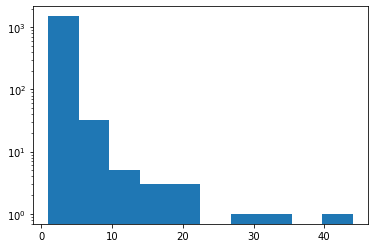

In [46]:
import matplotlib.pyplot as plt
plt.yscale('log')
plt.hist(list(rent_count_df["n"]))

In [207]:
alist = [[k, v] for k, v in adict.items()]
alist

[[1, 1243],
 [2, 159],
 [3, 54],
 [4, 30],
 [6, 12],
 [5, 17],
 [9, 8],
 [15, 2],
 [8, 3],
 [34, 1],
 [22, 1],
 [11, 1],
 [7, 9],
 [14, 1],
 [44, 1],
 [10, 4],
 [21, 1],
 [27, 1],
 [20, 1]]

## Pandas 5. Pivot to long- or wide-form

In [47]:
import pandas as pd
moi_df = pd.read_csv('https://github.com/P4CSS/PSS/raw/master/data/opendata108Y020.csv', error_bad_lines=False)
moi_df = moi_df[1:]
moi_df.drop(['statistic_yyy'], axis=1, inplace=True)

/var/folders/j3/p4x0mssx55nd8dn903h5wdb00000gn/T/ipykernel_8968/2169341433.py:2: FutureWarning: The error_bad_lines argument has been deprecated and will be removed in a future version. Use on_bad_lines in the future.


  moi_df = pd.read_csv('https://github.com/P4CSS/PSS/raw/master/data/opendata108Y020.csv', error_bad_lines=False)


In [49]:
moi_df['town'] = moi_df['site_id'].str[:3]

In [50]:
moi_df

,district_code,site_id,village,edu_age_15up_total,edu_doctor_graduated_m,edu_doctor_graduated_f,edu_doctor_ungraduated_m,edu_doctor_ungraduated_f,edu_master_graduated_m,edu_master_graduated_f,...,edu_juniorvocational_ungraduated_f,edu_primary_graduated_m,edu_primary_graduated_f,edu_primary_ungraduated_m,edu_primary_ungraduated_f,edu_selftaughtl_m,edu_selftaughtl_f,edu_illiterate_m,edu_illiterate_f,town
1,65000010001,新北市板橋區,留侯里,1441,5,1,2,2,51,31,...,0,26,71,2,6,0,2,0,3,新北市
2,65000010002,新北市板橋區,流芳里,1319,7,2,2,2,49,38,...,0,26,59,0,3,0,0,0,3,新北市
3,65000010003,新北市板橋區,赤松里,790,5,2,0,0,36,36,...,0,18,35,0,5,0,0,1,4,新北市
4,65000010004,新北市板橋區,黃石里,1012,4,2,3,0,27,44,...,0,25,54,0,4,0,0,1,2,新北市
5,65000010005,新北市板橋區,挹秀里,1703,16,5,5,2,88,65,...,0,20,53,5,4,0,1,1,2,新北市
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7756,09007030003,連江縣莒光鄉,西坵村,65,0,0,0,0,0,0,...,0,4,5,0,0,1,0,0,4,連江縣
7757,09007030004,連江縣莒光鄉,福正村,251,0,0,0,0,8,0,...,0,18,12,2,3,2,3,0,7,連江縣
7758,09007030005,連江縣莒光鄉,大坪村,503,0,0,0,0,12,7,...,0,27,39,1,8,2,3,2,16,連江縣
7759,09007040001,連江縣東引鄉,中柳村,551,1,0,2,0,16,15,...,0,20,22,5,4,0,3,2,10,連江縣


In [57]:
town_stat = moi_df.melt(id_vars=['district_code', 'site_id', 'village', 'town'])
town_stat.head()

,district_code,site_id,village,town,variable,value
0,65000010001,新北市板橋區,留侯里,新北市,edu_age_15up_total,1441
1,65000010002,新北市板橋區,流芳里,新北市,edu_age_15up_total,1319
2,65000010003,新北市板橋區,赤松里,新北市,edu_age_15up_total,790
3,65000010004,新北市板橋區,黃石里,新北市,edu_age_15up_total,1012
4,65000010005,新北市板橋區,挹秀里,新北市,edu_age_15up_total,1703


Separate columns into multiple columns
https://www.geeksforgeeks.org/python-pandas-split-strings-into-two-list-columns-using-str-split/

以下僅是拆掉`town_stat["variable"]`這個變項，但仍須依照上例把拆出來的新變項填回原本的`town_stat`中，但因為直接拆解的狀況不乾淨，所以這邊沒有操作。例如：
```Python
# making separate first name column from new data frame
town_stat["ageLower"]= new[2]
 
# making separate last name column from new data frame
town_stat["ageUpper"]= new[3]
```

In [61]:
new = town_stat["variable"].str.split("_", expand = True) 
new

,0,1,2,3,4,5
0,edu,age,15up,total,None,None
1,edu,age,15up,total,None,None
2,edu,age,15up,total,None,None
3,edu,age,15up,total,None,None
4,edu,age,15up,total,None,None
...,...,...,...,...,...,...
364715,edu,illiterate,f,None,None,None
364716,edu,illiterate,f,None,None,None
364717,edu,illiterate,f,None,None,None
364718,edu,illiterate,f,None,None,None
